In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [110]:
dataset = pd.read_csv("../datasets/salary_dataset.csv")

In [ ]:
dataset.head()
dataset.columns = dataset.columns.str.strip()


In [112]:
dataset.shape

(156, 3)

In [113]:
dataset.isnull().sum()

Age           0
Experience    0
Salary        0
dtype: int64

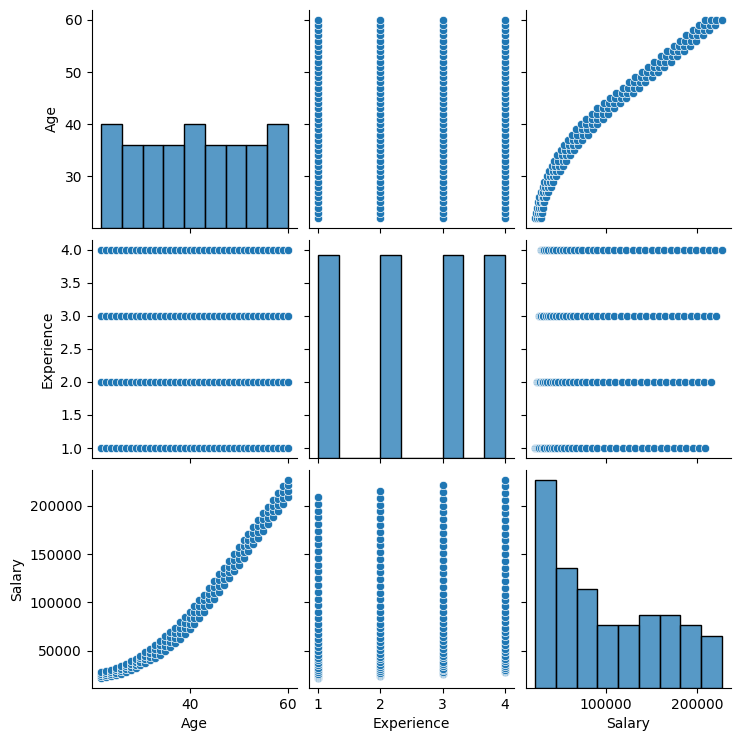

In [114]:
sns.pairplot(data=dataset)
plt.show()

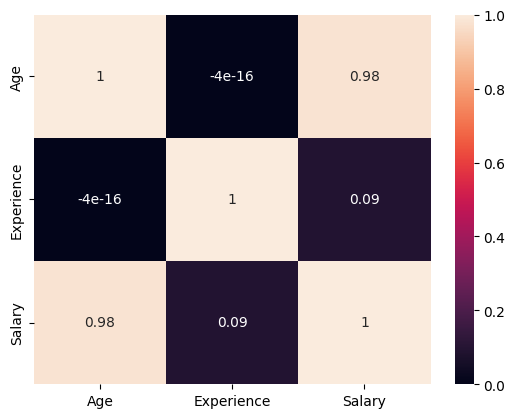

In [115]:
sns.heatmap(data=dataset.corr(),annot=True)
plt.show()

In [116]:
x = dataset.iloc[:,:-1]
y = dataset["Salary"]

In [117]:
dataset.shape

(156, 3)

In [118]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [119]:
lr = LinearRegression()

In [120]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [121]:
#y = m1x1+m2x2

In [122]:
lr.score(x_test,y_test)*100

96.75172092155279

In [123]:
lr.coef_

array([5353.53654254, 4828.31511685])

In [124]:
lr.intercept_

np.float64(-130775.54507856717)

y_prd = 5353.53654254*age + 4828.31511685 * experience -130775.54507856717

In [125]:
lr.predict(x_test)

array([120315.45099532,  87669.01031436, 108557.93505885,  93547.7682826 ,
       151386.2273992 ,  34133.64488892, 124618.54468648, 168497.27987822,
       119790.22956963, 188335.76177132,  27729.66549499, 119265.00814394,
        22376.12895245, 162618.52190998,  23951.79322952,  38961.96000577,
       161568.0790586 , 130497.30265472, 195264.96259094, 103204.3985163 ,
       129972.08122902,  22901.35037814,   7891.18360189,   7365.9621762 ,
        43790.27512262, 131022.52408041,  82840.69519751,  75911.49437789,
        70557.95783535, 125143.76611217,  55547.7910591 , 199042.83485641])

In [126]:
age = int(input("Enter Age: "))
experience = int(input("Enter Experience (years): "))

user_data = pd.DataFrame(
    [[age, experience]],
    columns=["Age", "Experience"]
)

predicted_salary = lr.predict(user_data)
predicted_salary


array([27204.4440693])

In [127]:
print(f"Predicted Salary: ₹{int(predicted_salary[0])}")


Predicted Salary: ₹27204
